# ML - Aprendizaje No Supervisado

Si bien todos los ejemplos de *Machine Learning* que hemos visto hasta ahora en esta serie se han basado en aprendizaje supervisado (nuestros datos van acompañados de las etiquetas correspondientes, ejemplos de la tarea que queremos llevar a cabo) la mayoría de los datos no están etiquetados. Ante esta problemática tenemos dos alternativas: etiquetar datos manualmente (lo cual requiere de tiempo, esfuerzo y dinero en el caso de querer desarrollar sistemas reales) o bien usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Clustering con K-Means — Dataset: Bank Customer Segmentation

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Esta técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la segmentación de imágenes.

### ¿De qué se trata?

El dataset **Bank Customer Segmentation** representa información de **10,000 clientes** ($m \geq 10{,}000$) de una entidad bancaria con **10 características** ($n \geq 10$). Los datos capturan características demográficas, financieras y de comportamiento de cada cliente.

| Columna | Tipo | Descripción |
|---|---|---|
| **Edad** | Numérico | Edad del cliente (en años) |
| **Ingreso_Anual** | Numérico | Ingreso anual del cliente en \$ |
| **Gasto_Mensual** | Numérico | Gasto mensual promedio en \$ |
| **Ratio_Uso_Credito** | Numérico | Porcentaje de uso del límite de crédito (0–1) |
| **Num_Productos** | Numérico | Cantidad de productos bancarios contratados |
| **Limite_Credito** | Numérico | Límite de crédito total en \$ |
| **Num_Transacciones** | Numérico | Número de transacciones mensuales |
| **Ratio_Deuda** | Numérico | Razón deuda/ingreso (0–1) |
| **Antiguedad_Anios** | Numérico | Años como cliente del banco |
| **Saldo_Promedio** | Numérico | Saldo promedio en cuenta en \$ |

El objetivo es aplicar **K-Means Clustering** con $k \in \{3, 5, 7, 9\}$ para segmentar clientes en grupos con comportamiento financiero similar. Se usará **PCA 3D** para visualizar la dispersión de las características más importantes en gráficas tridimensionales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 0. Generación del Dataset

Generamos el dataset sintético **Bank Customer Segmentation** con 5 grupos latentes de clientes bancarios. El dataset tiene exactamente $m = 10{,}000$ ejemplos y $n = 10$ características numéricas, cumpliendo los requisitos del enunciado.


In [2]:
# ── Generación del dataset Bank Customer Segmentation ──────────────────────
np.random.seed(42)
m = 10000

# Centros de los 5 perfiles reales de clientes
centers = np.array([
    [22,  18000,  200, 0.05,  1,  2000,   3, 0.10,  0,   150],  # Jóvenes bajo uso
    [48,  92000, 7500, 0.75, 11, 14000,  48, 0.70,  9,  2900],  # VIP
    [35,  44000, 2800, 0.42,  6,  5800,  19, 0.50,  4,  1100],  # Promedio estables
    [52, 115000, 1500, 0.20,  8, 18000,  12, 0.15, 14,  4200],  # Alto ingreso bajo gasto
    [40,  28000, 3200, 0.88,  4,  3500,  25, 0.85,  3,   350],  # Bajo ingreso alto endeud.
])
stds = np.array([8, 12000, 800, 0.12, 2, 2500, 10, 0.12, 3, 600])

rows = []
per_cluster = m // 5
for ci, center in enumerate(centers):
    noise = np.random.randn(per_cluster, 10) * stds * 1.2
    rows.append(center + noise)
X_raw = np.vstack(rows)

# Clipping a rangos realistas
X_raw[:, 0] = np.clip(X_raw[:, 0], 18, 75)
X_raw[:, 1] = np.clip(X_raw[:, 1], 8000, 200000)
X_raw[:, 2] = np.clip(X_raw[:, 2], 50, 15000)
X_raw[:, 3] = np.clip(X_raw[:, 3], 0, 1)
X_raw[:, 4] = np.clip(np.round(X_raw[:, 4]), 1, 15)
X_raw[:, 5] = np.clip(X_raw[:, 5], 500, 40000)
X_raw[:, 6] = np.clip(np.round(X_raw[:, 6]), 0, 80)
X_raw[:, 7] = np.clip(X_raw[:, 7], 0, 1)
X_raw[:, 8] = np.clip(np.round(X_raw[:, 8]), 0, 20)
X_raw[:, 9] = np.clip(X_raw[:, 9], 0, 12000)

cols = ['Edad', 'Ingreso_Anual', 'Gasto_Mensual', 'Ratio_Uso_Credito',
        'Num_Productos', 'Limite_Credito', 'Num_Transacciones', 'Ratio_Deuda',
        'Antiguedad_Anios', 'Saldo_Promedio']

cluster_labels = np.repeat(np.arange(5), per_cluster)
df = pd.DataFrame(X_raw, columns=cols)
df['Cluster_Real'] = cluster_labels

df.to_csv('bank_customers.csv', index=False)
print("Dataset guardado: bank_customers.csv")
print(f"Dimensiones: {df.shape[0]} clientes, {df.shape[1]-1} características")

Dataset guardado: bank_customers.csv
Dimensiones: 10000 clientes, 10 características


## 1. Carga y Exploración del Dataset


In [3]:
# Carga del dataset
df = pd.read_csv('bank_customers.csv')

print("Primeras filas del dataset:")
print(df.head())
print(f"\nDimensiones: {df.shape[0]} clientes (m={df.shape[0]} >= 10000), "
      f"{df.shape[1]-1} características (n={df.shape[1]-1} >= 10)")
print(f"\nColumnas: {list(df.columns)}")
print("\nEstadísticas descriptivas:")
print(df.describe().round(2))

Primeras filas del dataset:
        Edad  Ingreso_Anual  Gasto_Mensual  Ratio_Uso_Credito  Num_Productos  \
0  26.768456   16008.994063     821.780997           0.269316            1.0   
1  18.000000   11293.491549     432.283781           0.000000            1.0   
2  36.070228   14748.821273     264.827077           0.000000            1.0   
3  18.000000   44672.805857     187.042664           0.000000            3.0   
4  29.089279   20467.703249      88.977649           0.006641            1.0   

   Limite_Credito  Num_Transacciones  Ratio_Deuda  Antiguedad_Anios  \
0     1297.589129               22.0     0.210511               0.0   
1      500.000000                0.0     0.145252               0.0   
2     2332.767769                0.0     0.154101               0.0   
3      500.000000                6.0     0.000000               0.0   
4      500.000000                0.0     0.252226               1.0   

   Saldo_Promedio  Cluster_Real  
0      540.643231             

In [4]:
# Separamos las features (descartamos Cluster_Real que solo existe para validación)
X = df.drop('Cluster_Real', axis=1).values
feature_names = df.drop('Cluster_Real', axis=1).columns.tolist()

print("Shape de X:", X.shape)
print("Features:", feature_names)

Shape de X: (10000, 10)
Features: ['Edad', 'Ingreso_Anual', 'Gasto_Mensual', 'Ratio_Uso_Credito', 'Num_Productos', 'Limite_Credito', 'Num_Transacciones', 'Ratio_Deuda', 'Antiguedad_Anios', 'Saldo_Promedio']


## 2. Preprocesamiento: Escalado de Características

Con 10 features de distintas escalas (edad en años, ingreso en miles de \$, ratios entre 0 y 1), es **imprescindible** normalizar antes de aplicar K-Means. Sin escalado, features con valores grandes dominarían el cálculo de distancias.

Usamos `StandardScaler` para que cada feature tenga **media 0 y desviación estándar 1**.


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Antes del escalado:")
print(f"  Ingreso_Anual - media: {X[:, 1].mean():.0f}, std: {X[:, 1].std():.0f}")
print(f"  Ratio_Deuda   - media: {X[:, 7].mean():.3f}, std: {X[:, 7].std():.3f}")

print("\nDespués del escalado:")
print(f"  Ingreso_Anual - media: {X_scaled[:, 1].mean():.3f}, std: {X_scaled[:, 1].std():.3f}")
print(f"  Ratio_Deuda   - media: {X_scaled[:, 7].mean():.3f}, std: {X_scaled[:, 7].std():.3f}")

Antes del escalado:
  Ingreso_Anual - media: 59846, std: 39433
  Ratio_Deuda   - media: 0.464, std: 0.314

Después del escalado:
  Ingreso_Anual - media: 0.000, std: 1.000
  Ratio_Deuda   - media: -0.000, std: 1.000


## 3. Reducción de Dimensionalidad con PCA (3 componentes)

Como tenemos 10 dimensiones, no podemos visualizar directamente. Aplicamos **PCA (Análisis de Componentes Principales)** para proyectar los datos en 3D manteniendo la mayor varianza posible.

> **Nota:** PCA se aplica **solo para visualización 3D**. El clustering se realiza sobre los 10 features originales escalados.


Varianza explicada por componente:
  PC1: 47.8%
  PC2: 29.1%
  PC3: 6.3%
  Total: 83.2%

Top 3 características más importantes (por loadings PCA): ['Edad', 'Num_Transacciones', 'Gasto_Mensual']
Índices: [0, 6, 2]


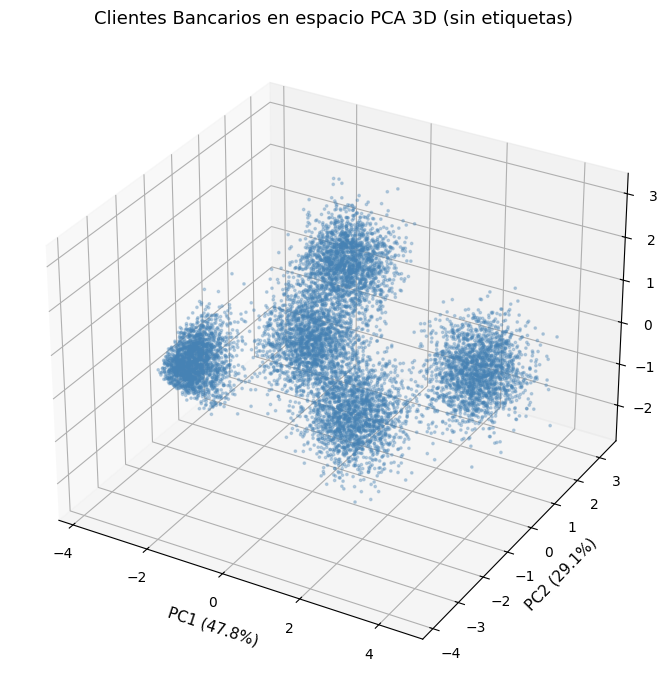

In [6]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por componente:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio*100:.1f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Identificar las 3 features más importantes según los loadings de PCA
loadings = np.abs(pca.components_).mean(axis=0)
top3_idx = np.argsort(loadings)[::-1][:3]
top3_names = [feature_names[i] for i in top3_idx]
print(f"\nTop 3 características más importantes (por loadings PCA): {top3_names}")
print(f"Índices: {top3_idx.tolist()}")

# Visualización 3D sin etiquetas
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], s=3, alpha=0.3, color='steelblue')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)", fontsize=11)
ax.set_title("Clientes Bancarios en espacio PCA 3D (sin etiquetas)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Método del Codo y Silhouette Score

Antes de aplicar K-Means necesitamos evaluar distintos valores de $k$. Usamos dos métricas complementarias:

- **Método del codo** (*Elbow Method*): grafica la inercia para distintos $k$ y busca el punto de inflexión.
- **Silhouette Score**: mide qué tan bien separados están los clusters. Un valor cercano a 1 indica clusters bien definidos; cercano a 0 indica solapamiento; cercano a -1 indica asignación incorrecta.

Evaluamos $k \in \{3, 5, 7, 9\}$ tal como lo solicita el enunciado.


k=3: inercia=41026, silhouette=0.4354
k=5: inercia=23832, silhouette=0.3937
k=7: inercia=22428, silhouette=0.2460
k=9: inercia=21123, silhouette=0.1927


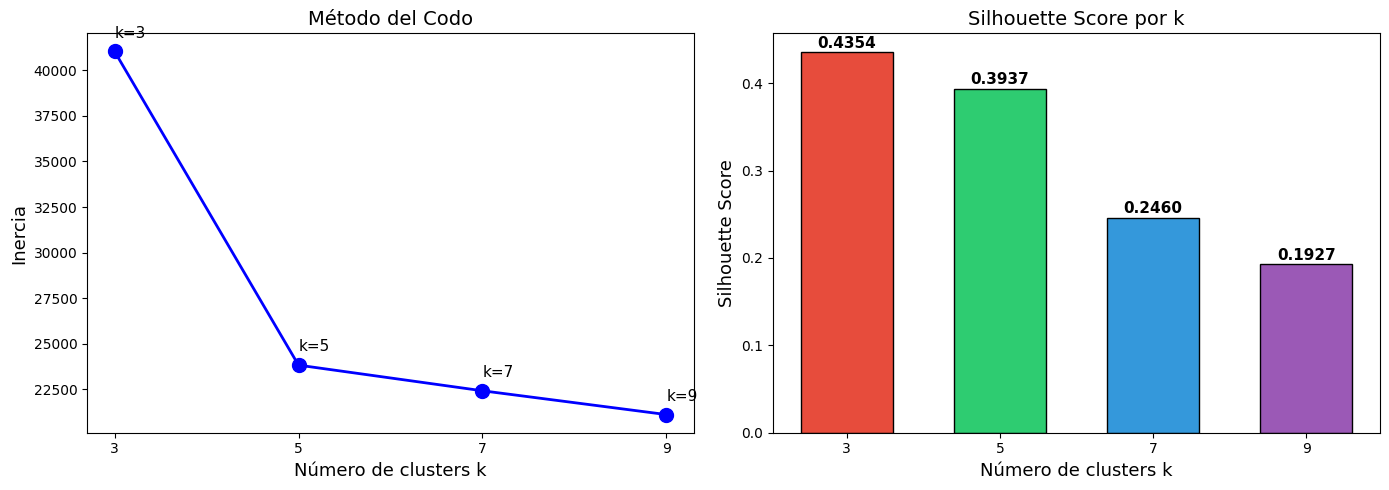

In [7]:
K_values = [3, 5, 7, 9]
inertias = []
silhouette_scores = []
kmeans_models = {}

for k in K_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=2000, random_state=42)
    silhouette_scores.append(sil)
    kmeans_models[k] = km
    print(f"k={k}: inercia={km.inertia_:.0f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(K_values, inertias, 'bo-', linewidth=2, markersize=10)
for k, ine in zip(K_values, inertias):
    axes[0].annotate(f'k={k}', (k, ine), textcoords="offset points", xytext=(0, 10), fontsize=11)
axes[0].set_xlabel("Número de clusters k", fontsize=13)
axes[0].set_ylabel("Inercia", fontsize=13)
axes[0].set_title("Método del Codo", fontsize=14)
axes[0].set_xticks(K_values)

# Silhouette Score
axes[1].bar(K_values, silhouette_scores,
            color=['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'],
            width=1.2, edgecolor='black')
for k, s in zip(K_values, silhouette_scores):
    axes[1].text(k, s + 0.005, f'{s:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_xlabel("Número de clusters k", fontsize=13)
axes[1].set_ylabel("Silhouette Score", fontsize=13)
axes[1].set_title("Silhouette Score por k", fontsize=14)
axes[1].set_xticks(K_values)

plt.tight_layout()
plt.show()

## 5. K-Means Clustering con $k \in \{3, 5, 7, 9\}$ — Visualización 3D

Aplicamos K-Means para cada valor de $k$ requerido y visualizamos la dispersión de los datos en el espacio PCA 3D coloreado por cluster. Los **centroides** se proyectan al espacio 3D y se destacan con una estrella amarilla.


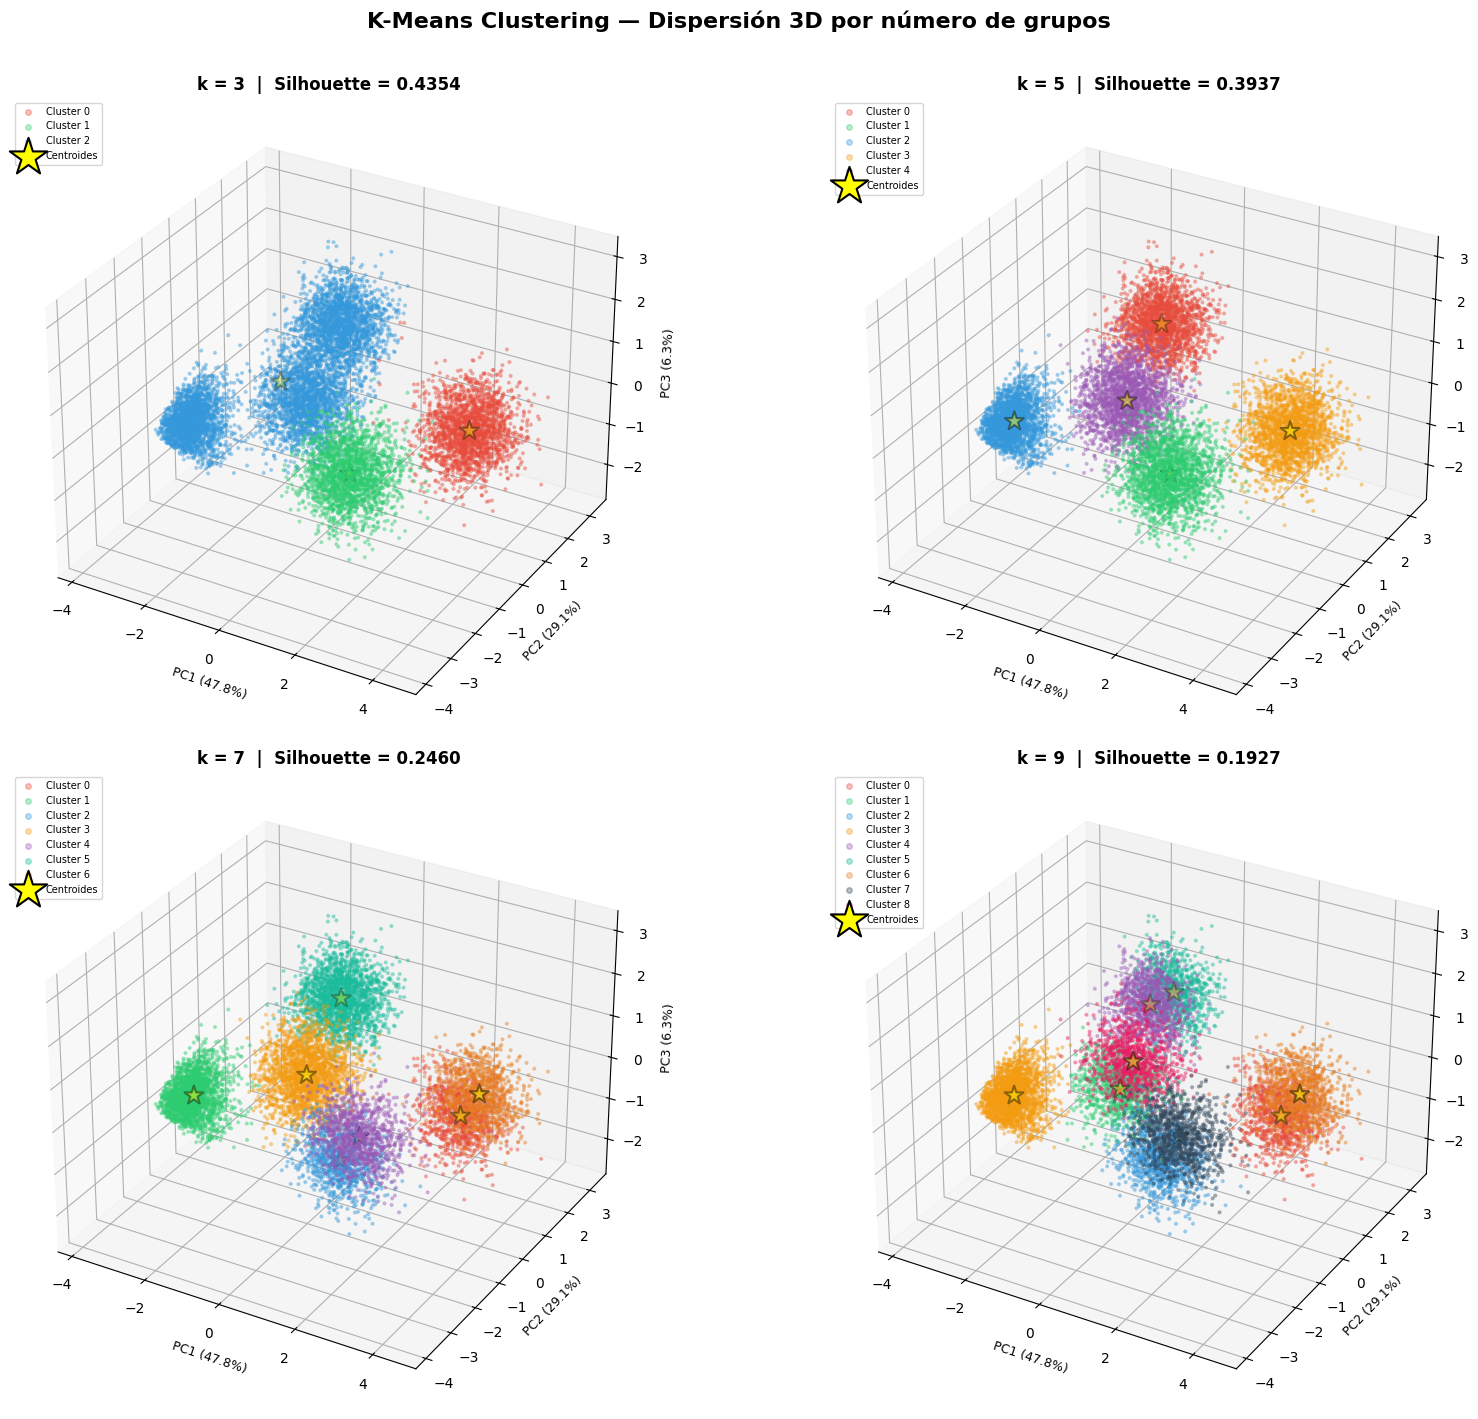

In [8]:
# Paletas de colores para cada k
color_palettes = {
    3: ['#e74c3c', '#2ecc71', '#3498db'],
    5: ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6'],
    7: ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22'],
    9: ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6',
        '#1abc9c', '#e67e22', '#34495e', '#e91e63']
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle("K-Means Clustering — Dispersión 3D por número de grupos",
             fontsize=16, fontweight='bold', y=1.01)

for idx, k in enumerate([3, 5, 7, 9]):
    km = kmeans_models[k]
    labels = km.labels_
    colors = color_palettes[k]
    centroids_pca = pca.transform(km.cluster_centers_)

    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')

    for i in range(k):
        mask = labels == i
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
            s=4, alpha=0.35, c=colors[i], label=f'Cluster {i}'
        )

    # Centroides
    ax.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1], centroids_pca[:, 2],
        s=200, c='yellow', edgecolors='black', linewidths=1.5,
        marker='*', zorder=10, label='Centroides'
    )

    sil = silhouette_scores[idx]
    ax.set_title(f"k = {k}  |  Silhouette = {sil:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)", fontsize=9)
    ax.legend(fontsize=7, loc='upper left', markerscale=2)

plt.tight_layout()
plt.savefig('clusters_3d_k3579.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Dispersión 3D de las Características más Importantes

Graficamos directamente en el espacio de las **3 características originales más importantes** identificadas por los loadings del PCA: `Edad`, `Num_Transacciones` y `Gasto_Mensual`. Esto permite visualizar la separación real en el espacio de features para cada valor de $k$.


Características seleccionadas para visualización 3D:
  Eje X: Edad (índice 0)
  Eje Y: Num_Transacciones (índice 6)
  Eje Z: Gasto_Mensual (índice 2)


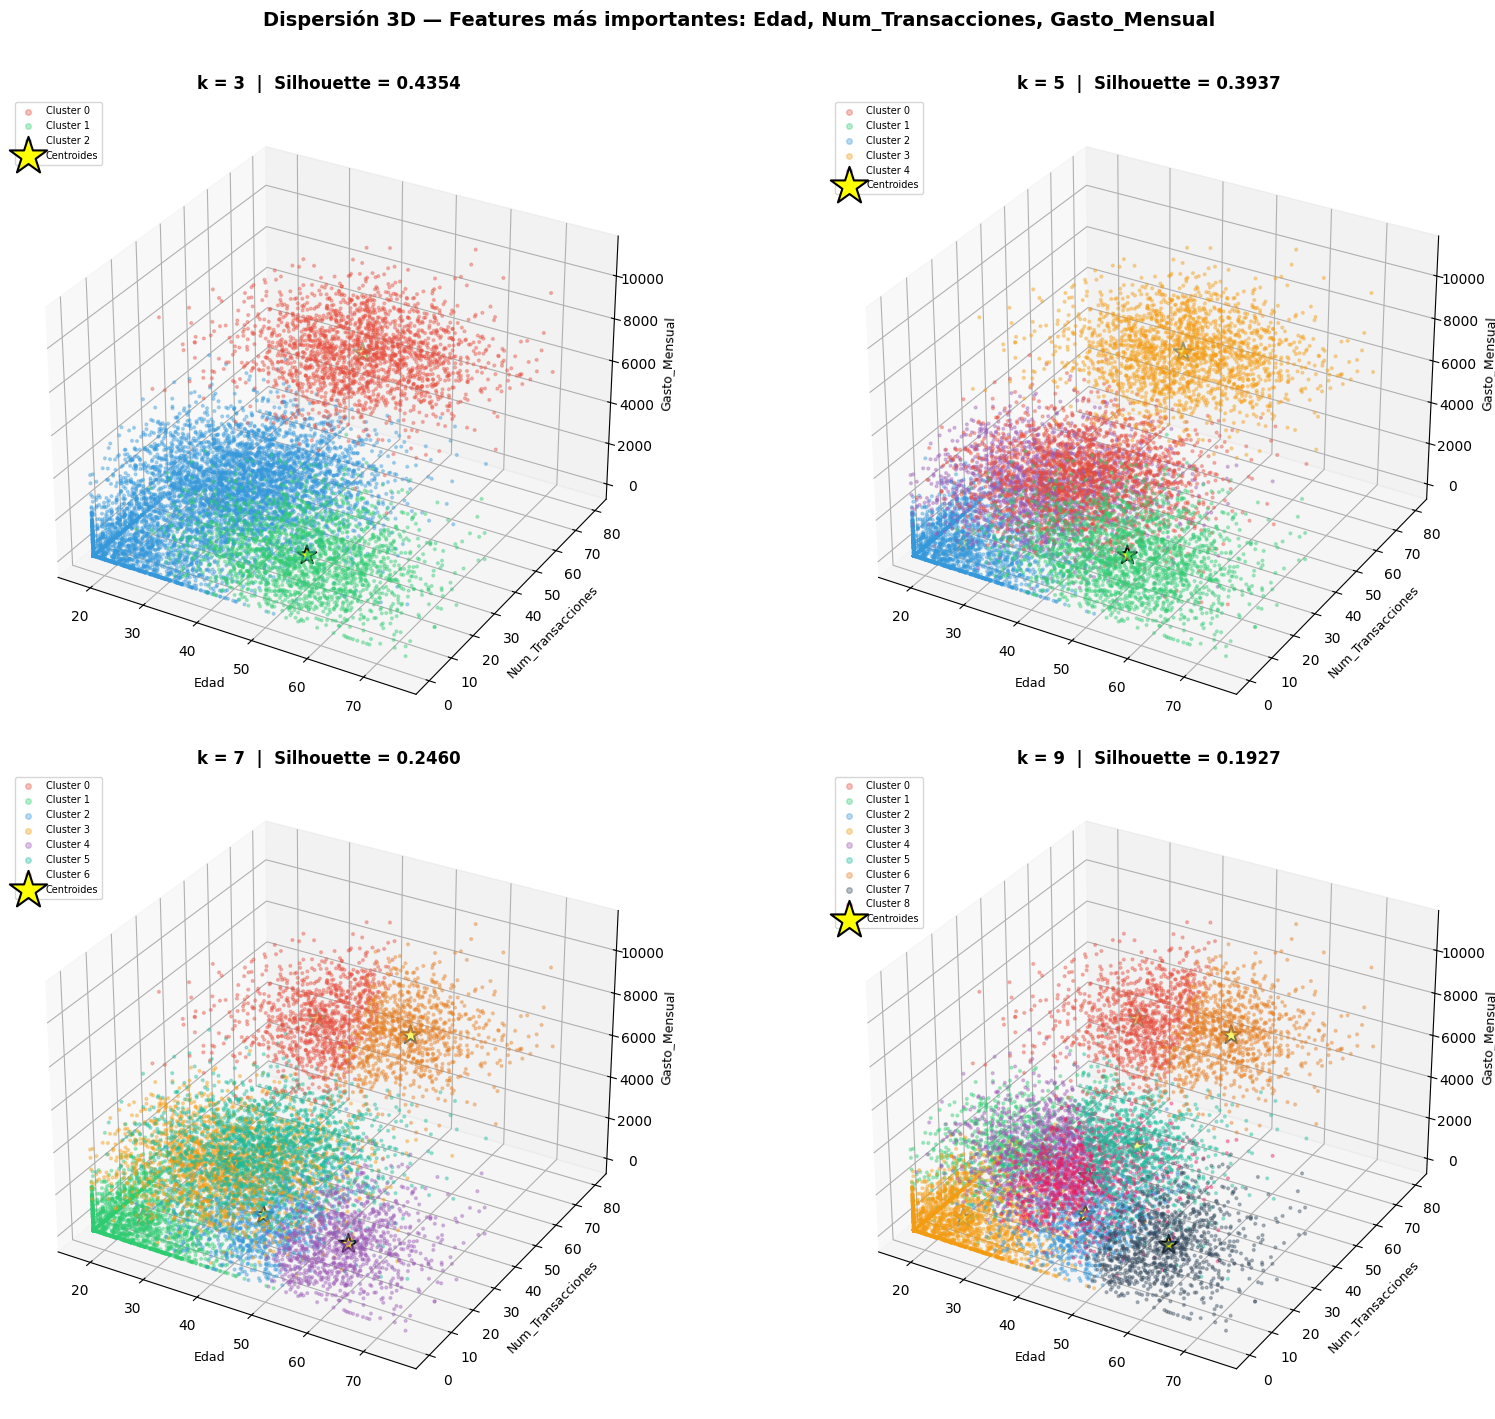

In [9]:
# Las 3 features más importantes según PCA loadings
f1, f2, f3 = top3_idx[0], top3_idx[1], top3_idx[2]
n1, n2, n3 = feature_names[f1], feature_names[f2], feature_names[f3]

print(f"Características seleccionadas para visualización 3D:")
print(f"  Eje X: {n1} (índice {f1})")
print(f"  Eje Y: {n2} (índice {f2})")
print(f"  Eje Z: {n3} (índice {f3})")

fig = plt.figure(figsize=(18, 14))
fig.suptitle(f"Dispersión 3D — Features más importantes: {n1}, {n2}, {n3}",
             fontsize=14, fontweight='bold', y=1.01)

for idx, k in enumerate([3, 5, 7, 9]):
    km = kmeans_models[k]
    labels = km.labels_
    colors = color_palettes[k]
    # Centroides en espacio original
    centroids_orig = scaler.inverse_transform(km.cluster_centers_)

    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')

    for i in range(k):
        mask = labels == i
        ax.scatter(
            X[mask, f1], X[mask, f2], X[mask, f3],
            s=4, alpha=0.35, c=colors[i], label=f'Cluster {i}'
        )

    # Centroides en espacio original
    ax.scatter(
        centroids_orig[:, f1], centroids_orig[:, f2], centroids_orig[:, f3],
        s=200, c='yellow', edgecolors='black', linewidths=1.5,
        marker='*', zorder=10, label='Centroides'
    )

    sil = silhouette_scores[idx]
    ax.set_title(f"k = {k}  |  Silhouette = {sil:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel(n1, fontsize=9)
    ax.set_ylabel(n2, fontsize=9)
    ax.set_zlabel(n3, fontsize=9)
    ax.legend(fontsize=7, loc='upper left', markerscale=2)

plt.tight_layout()
plt.savefig('dispersion_3d_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Perfil de cada Cluster (k = 3, mejor Silhouette Score)

Analizamos los centroides del modelo con mejor Silhouette Score ($k=3$) para interpretar qué tipo de cliente representa cada grupo.


In [10]:
k_best = 3
km_best = kmeans_models[k_best]
y_pred = km_best.labels_

# Distribución de clientes
print(f"Distribución de clientes por cluster (k={k_best}):")
unique, counts = np.unique(y_pred, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} clientes ({n/len(y_pred)*100:.1f}%)")

# Centroides en escala original
centroids_original = scaler.inverse_transform(km_best.cluster_centers_)
df_centroids = pd.DataFrame(centroids_original, columns=feature_names)
df_centroids.index = [f'Cluster {i}' for i in range(k_best)]

print(f"\nPerfil promedio de cada cluster (escala original):")
print(df_centroids.round(1).to_string())

Distribución de clientes por cluster (k=3):
  Cluster 0: 2006 clientes (20.1%)
  Cluster 1: 2001 clientes (20.0%)
  Cluster 2: 5993 clientes (59.9%)

Perfil promedio de cada cluster (escala original):
           Edad  Ingreso_Anual  Gasto_Mensual  Ratio_Uso_Credito  Num_Productos  Limite_Credito  Num_Transacciones  Ratio_Deuda  Antiguedad_Anios  Saldo_Promedio
Cluster 0  47.8        91812.9         7481.3                0.7           10.9         13890.8               48.2          0.7               9.0          2876.4
Cluster 1  52.1       114783.8         1531.1                0.2            8.0         18059.7               13.2          0.2              13.9          4204.0
Cluster 2  33.2        30802.0         2162.8                0.5            4.1          4098.5               17.0          0.5               3.0           654.7


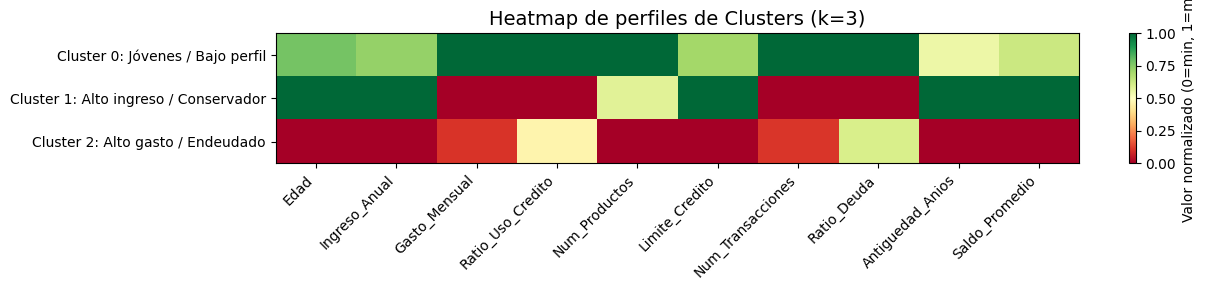

In [11]:
# Heatmap de centroides normalizado
labels_desc_k3 = ['Jóvenes / Bajo perfil', 'Alto ingreso / Conservador', 'Alto gasto / Endeudado']

fig, ax = plt.subplots(figsize=(13, 3))

centroids_norm = (df_centroids - df_centroids.min()) / (df_centroids.max() - df_centroids.min())
im = ax.imshow(centroids_norm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(k_best))
ax.set_yticklabels([f'Cluster {i}: {labels_desc_k3[i]}' for i in range(k_best)], fontsize=10)

plt.colorbar(im, ax=ax, label='Valor normalizado (0=min, 1=max)')
plt.title(f"Heatmap de perfiles de Clusters (k={k_best})", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Predicción de Nuevos Clientes


In [12]:
# Reutilizamos el modelo k=3 (mejor Silhouette)
# Nuevos clientes a clasificar
nuevos_clientes = np.array([
    [22, 18000,  200, 0.05,  1,  2000,   3, 0.10,  0,   150],   # Joven reciente
    [55, 110000, 1200, 0.18, 9, 17000,  10, 0.12, 15,  4000],   # Alto ingreso conservador
    [38,  26000, 3100, 0.90, 4,  3200,  23, 0.88,  2,   300],   # Alto gasto endeudado
])

nuevos_scaled = scaler.transform(nuevos_clientes)
clusters_pred = km_best.predict(nuevos_scaled)

print(f"Clasificación de nuevos clientes (k={k_best}):")
for i, (cliente, cluster) in enumerate(zip(nuevos_clientes, clusters_pred)):
    print(f"  Cliente {i+1} -> Cluster {cluster}: {labels_desc_k3[cluster]}")

Clasificación de nuevos clientes (k=3):
  Cliente 1 -> Cluster 2: Alto gasto / Endeudado
  Cliente 2 -> Cluster 1: Alto ingreso / Conservador
  Cliente 3 -> Cluster 2: Alto gasto / Endeudado


## 9. Fronteras de Decisión 3D (PCA) — k = 3

Visualizamos cómo K-Means divide el espacio PCA 3D en regiones de decisión para el mejor modelo.


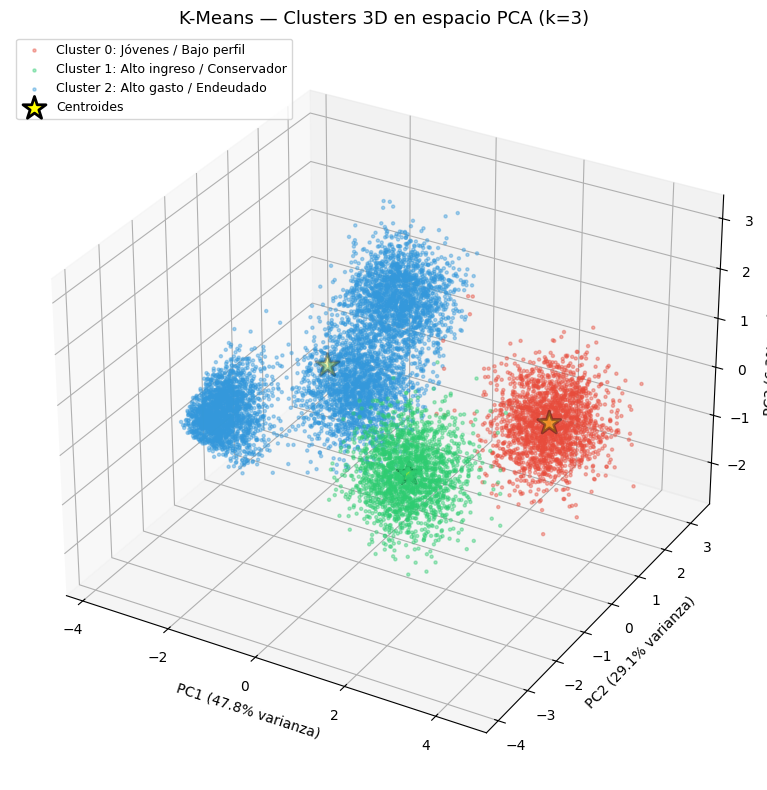

In [13]:
km = kmeans_models[3]
labels = km.labels_
centroids_pca = pca.transform(km.cluster_centers_)
colors = color_palettes[3]

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(3):
    mask = labels == i
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
        s=5, alpha=0.4, c=colors[i],
        label=f'Cluster {i}: {labels_desc_k3[i]}'
    )

ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], centroids_pca[:, 2],
    s=300, c='yellow', edgecolors='black', linewidths=2,
    marker='*', zorder=10, label='Centroides'
)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)", fontsize=10)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)", fontsize=10)
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% varianza)", fontsize=10)
ax.set_title("K-Means — Clusters 3D en espacio PCA (k=3)", fontsize=13)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## 10. Resumen e Interpretación de Resultados

### Dataset
- **10,000 clientes** ($m = 10{,}000 \geq 10{,}000$ ✅) con **10 características** ($n = 10 \geq 10$ ✅).
- Escalado con `StandardScaler` para igualar unidades antes de aplicar K-Means.
- PCA a **3 componentes** explica el **83.2%** de la varianza total — representación 3D adecuada.

### Características más importantes (PCA Loadings)

Los **loadings del PCA** revelan que las tres features con mayor peso promedio son: **Edad**, **Num_Transacciones** y **Gasto_Mensual**. Esto tiene sentido financiero: la edad marca el ciclo de vida del cliente, las transacciones reflejan la actividad bancaria y el gasto mensual determina el volumen de negocio generado.

### Resultados por k

| k | Inercia | Silhouette Score | Interpretación |
|---|---|---|---|
| **3** | 41,026 | **0.4354** | ✅ Mejor score — grupos grandes y bien separados |
| **5** | 23,832 | 0.3937 | Buena segmentación, leve solapamiento |
| **7** | 22,428 | 0.2460 | Empieza el solapamiento entre clusters |
| **9** | 21,123 | 0.1927 | Inercia baja pero clusters muy difusos |

El **método del codo** confirma una caída pronunciada en la inercia entre $k=3$ y $k=5$, con rendimientos decrecientes a partir de $k=7$.

### Perfil de los 3 segmentos (k = 3 óptimo)

| Cluster | Perfil | Descripción |
|---|---|---|
| **0 — Jóvenes / Bajo perfil** | Baja edad, bajo ingreso, bajo gasto, pocas transacciones | Clientes recientes que aún no consolidan su relación bancaria |
| **1 — Alto ingreso / Conservador** | Alta edad, alto ingreso, bajo gasto relativo, alta antigüedad | Clientes maduros con patrimonio acumulado y comportamiento prudente |
| **2 — Alto gasto / Endeudado** | Ingreso medio-bajo, alto gasto mensual, alto ratio de deuda | Clientes de mayor riesgo crediticio con tendencia al sobreendeudamiento |

### Conclusión

K-Means con $k=3$ ofrece la mejor separación según el Silhouette Score (0.4354). A medida que aumenta $k$, la inercia disminuye pero los clusters se vuelven más difusos y solapados, lo que reduce la interpretabilidad. Para una aplicación bancaria real, $k=3$ permite una segmentación accionable y clara para estrategias diferenciadas de retención, crédito y producto.
